<a href="https://colab.research.google.com/github/davesagit123/blank-app/blob/main/LINEAR_REGRESSION_DIAGNOSTICS_LEVERAGE%2C_OUTLIERS%2C_%26_INFLUENTIAL_POINTS_Based_on_Goldsmith_(2016)_Linear_Regression_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:119: SyntaxWarning: invalid escape sequence '\h'
<>:119: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_806/26106224.py:119: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_xlabel("Fitted Values ($\hat{y}$)")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                     55.00
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           1.70e-09
Time:                        00:32:44   Log-Likelihood:                -113.76
No. Observations:                  50   AIC:                             231.5
Df Residuals:                      48   BIC:                             235.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7149      0.805      4.617      0.0

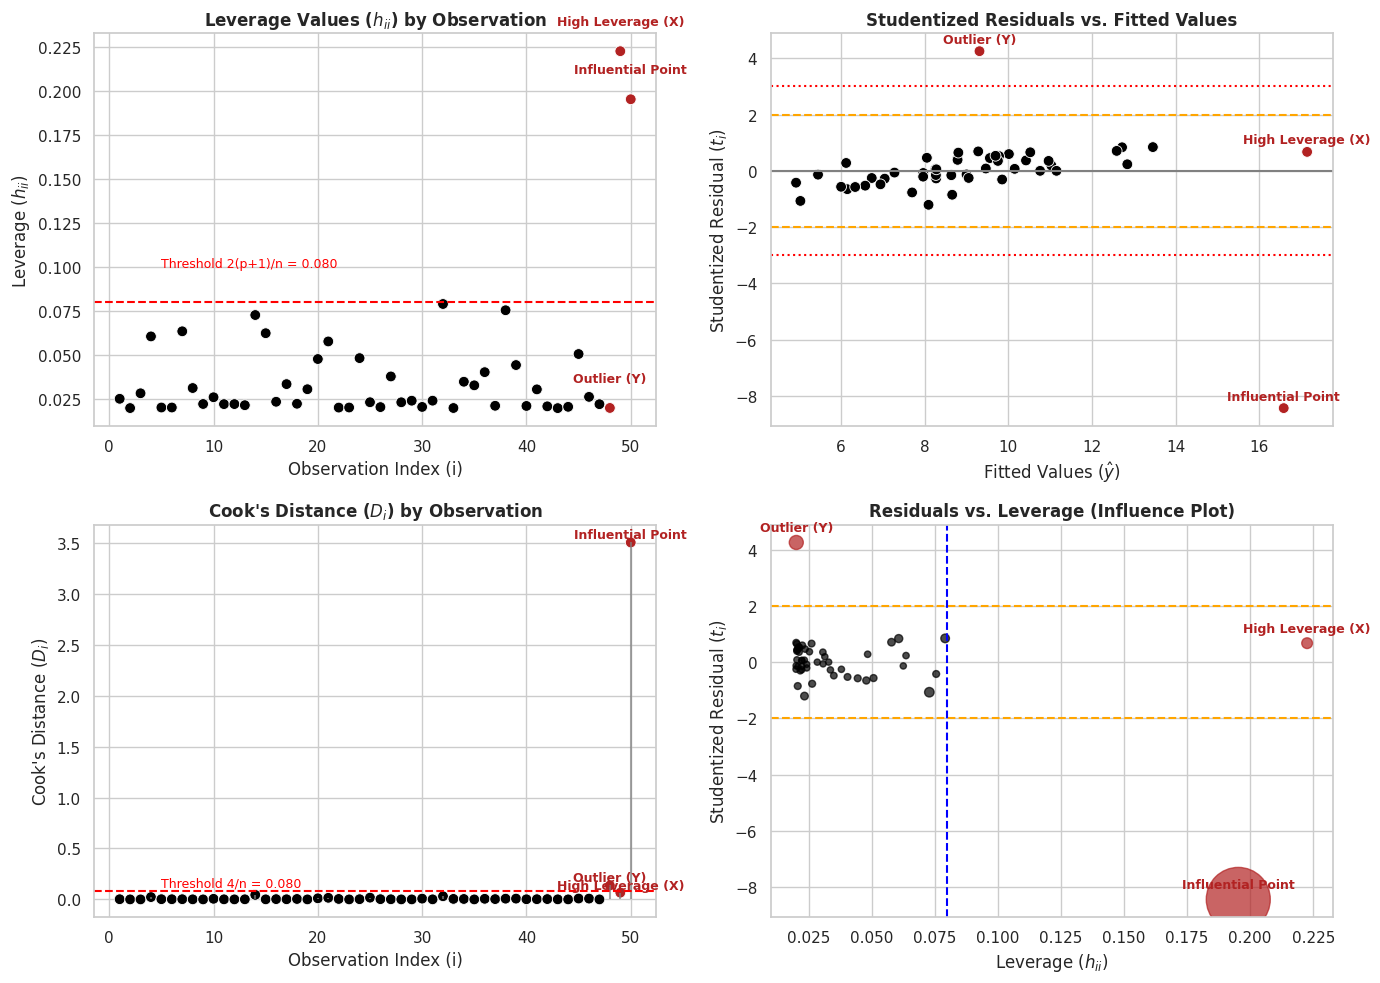

In [1]:
# ==============================================================================
# LINEAR REGRESSION DIAGNOSTICS IN PYTHON (GOOGLE COLAB)
# Leverage, Outliers, & Influential Points
# ==============================================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# ------------------------------------------------------------------------------
# 1. GENERATE SYNTHETIC DATA & FIT MODEL
# ------------------------------------------------------------------------------
np.random.seed(42)
n = 50

# Normal observations
x = np.random.normal(loc=5.0, scale=2.0, size=n)
y = 2.0 + 1.5 * x + np.random.normal(loc=0.0, scale=1.0, size=n)

# Inject diagnostic anomalies matching the R script:
# Observation 48 (index 47 in 0-indexed Python): Outlier in Y
x[47] = 5.0
y[47] = 18.0

# Observation 49 (index 48): High leverage point (extreme X, follows line)
x[48] = 12.0
y[48] = 2.0 + 1.5 * 12.0 + np.random.normal(0, 1)

# Observation 50 (index 49): Influential point (extreme X, does NOT follow line)
x[49] = 11.5
y[49] = 5.0

# Build Dataframe (1-indexed ID for easy comparison with R script)
df = pd.DataFrame({
    'id': np.arange(1, n + 1),
    'x': x,
    'y': y
})

# Fit OLS Regression Model (add constant for intercept)
X = sm.add_constant(df['x'])
model = sm.OLS(df['y'], X).fit()

# Print standard summary
print(model.summary())

# ------------------------------------------------------------------------------
# 2. EXTRACT DIAGNOSTIC MEASURES
# ------------------------------------------------------------------------------
influence = model.get_influence()

df['fitted'] = model.fittedvalues
df['leverage'] = influence.hat_matrix_diag
df['student_resid'] = influence.resid_studentized_external  # Studentized deletion residuals
df['cooksd'] = influence.cooks_distance[0]

# Add labels for injected anomalies
def label_point(row):
    if row['id'] == 48:
        return "Outlier (Y)"
    elif row['id'] == 49:
        return "High Leverage (X)"
    elif row['id'] == 50:
        return "Influential Point"
    return None

df['label'] = df.apply(label_point, axis=1)

# ------------------------------------------------------------------------------
# 3. DIAGNOSTIC PLOTS (2x2 GRID)
# ------------------------------------------------------------------------------
p = 1  # Number of predictors (excluding intercept)
n_obs = len(df)
leverage_threshold = 2 * (p + 1) / n_obs
cooks_threshold = 4 / n_obs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- PLOT 1: Leverage Values (h_ii) vs. Index ---
ax1 = axes[0, 0]
sns.scatterplot(
    data=df, x='id', y='leverage',
    hue=df['label'].notna(), palette={False: 'black', True: 'firebrick'},
    s=60, legend=False, ax=ax1
)
ax1.axhline(leverage_threshold, color='red', linestyle='--', linewidth=1.5)
ax1.set_title("Leverage Values ($h_{ii}$) by Observation", fontweight='bold')
ax1.set_xlabel("Observation Index (i)")
ax1.set_ylabel("Leverage ($h_{ii}$)")
ax1.annotate(f'Threshold 2(p+1)/n = {leverage_threshold:.3f}',
             xy=(1, leverage_threshold), xytext=(5, leverage_threshold + 0.02),
             color='red', fontsize=9)

# Label anomalies
for _, row in df[df['label'].notna()].iterrows():
    ax1.text(row['id'], row['leverage'] + 0.015, row['label'], color='firebrick',
             fontweight='bold', fontsize=9, ha='center')


# --- PLOT 2: Studentized Residuals vs. Fitted Values ---
ax2 = axes[0, 1]
sns.scatterplot(
    data=df, x='fitted', y='student_resid',
    hue=df['label'].notna(), palette={False: 'black', True: 'firebrick'},
    s=60, legend=False, ax=ax2
)
ax2.axhline(0, color='gray', linestyle='-')
ax2.axhline(2, color='orange', linestyle='--', label='±2 Warning')
ax2.axhline(-2, color='orange', linestyle='--')
ax2.axhline(3, color='red', linestyle=':', label='±3 Extreme')
ax2.axhline(-3, color='red', linestyle=':')
ax2.set_title("Studentized Residuals vs. Fitted Values", fontweight='bold')
ax2.set_xlabel("Fitted Values ($\hat{y}$)")
ax2.set_ylabel("Studentized Residual ($t_i$)")

for _, row in df[df['label'].notna()].iterrows():
    ax2.text(row['fitted'], row['student_resid'] + 0.3, row['label'], color='firebrick',
             fontweight='bold', fontsize=9, ha='center')


# --- PLOT 3: Cook's Distance (D_i) vs. Index ---
ax3 = axes[1, 0]
# Stem/needle plot
ax3.vlines(x=df['id'], ymin=0, ymax=df['cooksd'], color='gray', alpha=0.7)
sns.scatterplot(
    data=df, x='id', y='cooksd',
    hue=df['label'].notna(), palette={False: 'black', True: 'firebrick'},
    s=60, legend=False, ax=ax3
)
ax3.axhline(cooks_threshold, color='red', linestyle='--', linewidth=1.5)
ax3.set_title("Cook's Distance ($D_i$) by Observation", fontweight='bold')
ax3.set_xlabel("Observation Index (i)")
ax3.set_ylabel("Cook's Distance ($D_i$)")
ax3.annotate(f'Threshold 4/n = {cooks_threshold:.3f}',
             xy=(1, cooks_threshold), xytext=(5, cooks_threshold + 0.05),
             color='red', fontsize=9)

for _, row in df[df['label'].notna()].iterrows():
    ax3.text(row['id'], row['cooksd'] + 0.04, row['label'], color='firebrick',
             fontweight='bold', fontsize=9, ha='center')


# --- PLOT 4: Residuals vs. Leverage (Influence Plot) ---
ax4 = axes[1, 1]
scatter = ax4.scatter(
    df['leverage'], df['student_resid'],
    s=df['cooksd'] * 600 + 20, # Scale marker size by Cook's distance
    c=df['label'].notna().map({False: 'black', True: 'firebrick'}),
    alpha=0.7
)
ax4.axhline(2, color='orange', linestyle='--')
ax4.axhline(-2, color='orange', linestyle='--')
ax4.axvline(leverage_threshold, color='blue', linestyle='--')
ax4.set_title("Residuals vs. Leverage (Influence Plot)", fontweight='bold')
ax4.set_xlabel("Leverage ($h_{ii}$)")
ax4.set_ylabel("Studentized Residual ($t_i$)")

for _, row in df[df['label'].notna()].iterrows():
    ax4.text(row['leverage'], row['student_resid'] + 0.4, row['label'], color='firebrick',
             fontweight='bold', fontsize=9, ha='center')

plt.tight_layout()
plt.show()

horse sectionals version

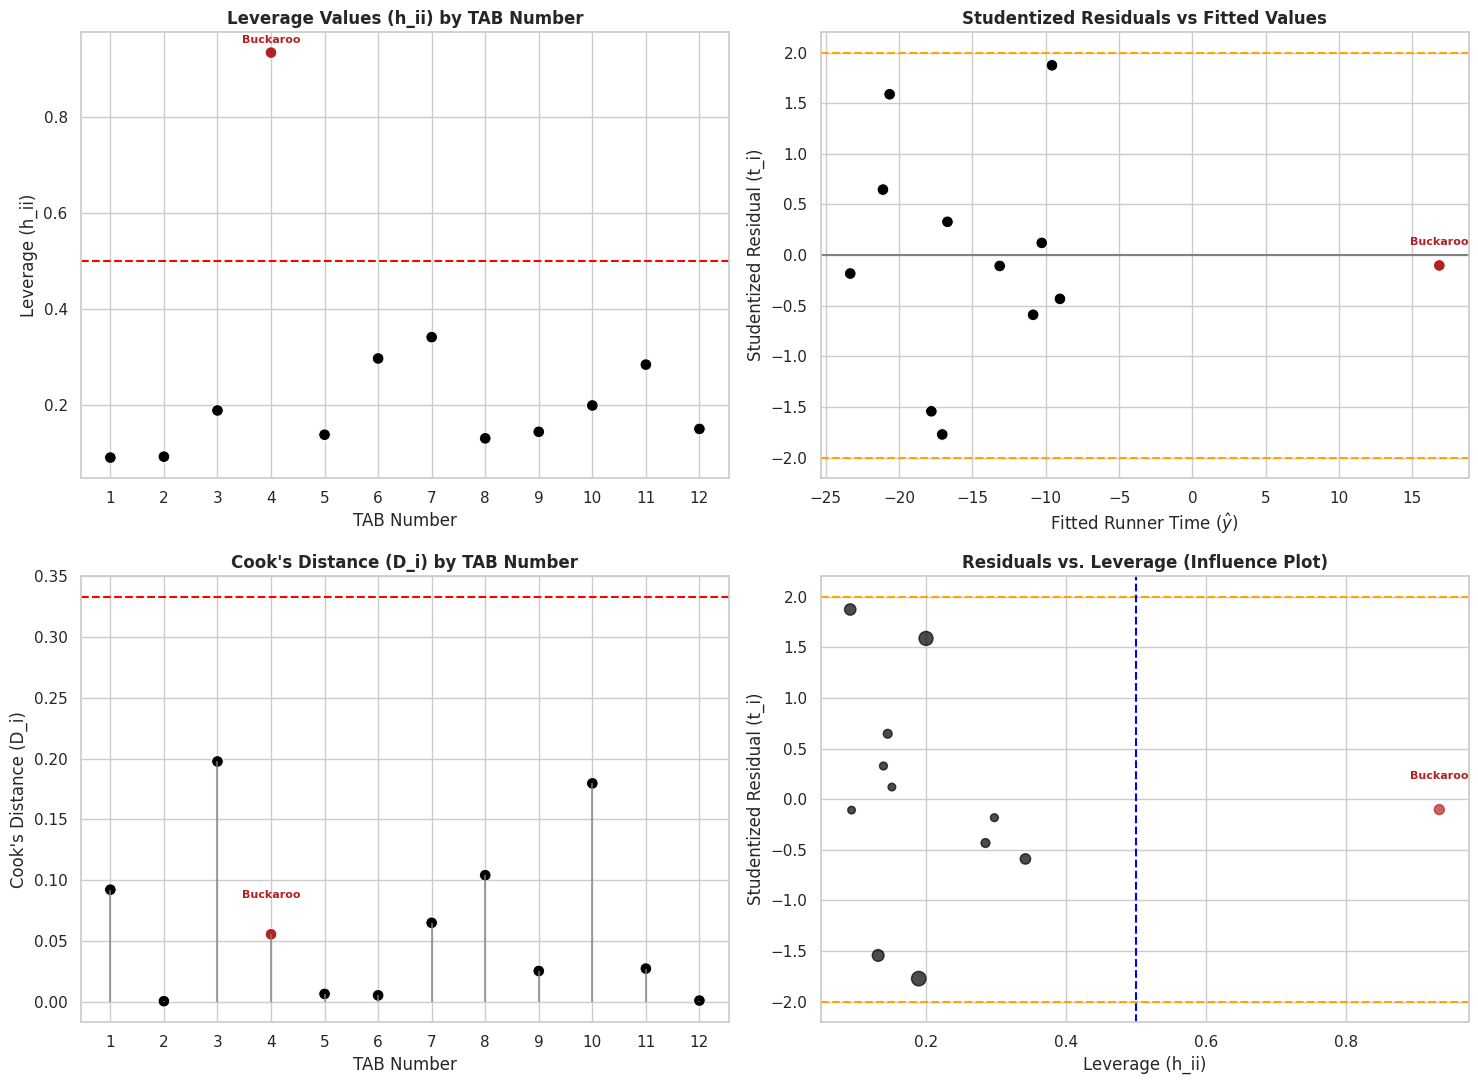


--- FLAGGED RUNNERS ---
   tab_num runner_name  runner_time  early_pace  leverage  student_resid  \
3        4    Buckaroo        16.76          58  0.933986      -0.102363   

    cooksd  
3  0.05552  


In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------------------
# 1. PARSE & CLEAN THE SECTIONAL DATA
# ------------------------------------------------------------------------------
data = """
tab_num	runner_name	runner_time	early_pace	split_800m	split_600m	split_400m	split_200m
1	Mr Brightside	-5.23L	65	-1.65L	-1.43L	-0.71L	+0.01L
2	Jimmysstar	-13.44L	64	-2.41L	-2.26L	-1.87L	-1.05L
3	Tom Kitten	-21.01L	80	-1.84L	-1.18L	-0.42L	-0.06L
4	Buckaroo	+16.76L	58	+2.80L	+3.68L	+4.07L	+4.45L
5	Angel Capital	-15.82L	63	-3.17L	-2.62L	-1.85L	-0.99L
6	Birdman	-23.78L	86	-2.54L	-1.54L	-0.49L	+0.06L
7	Cosmic Crusader	-12.23L	49	-3.21L	-2.49L	-1.92L	-0.86L
8	Sabaj	-21.49L	76	-2.31L	-1.59L	-0.86L	-0.20L
9	Autumn Boy	-19.40L	75	-3.02L	-2.49L	-1.81L	-0.65L
10	Beiwacht	-17.03L	81	-2.44L	-2.20L	-1.65L	-0.72L
11	Planet Red	-10.09L	50	-2.78L	-2.17L	-1.49L	-0.79L
12	Treasurethe Moment	-9.95L	57	-2.44L	-1.83L	-1.07L	-0.45L
"""

# Load into DataFrame
from io import StringIO
df = pd.read_csv(StringIO(data.strip()), sep='\t')

# Convert text length values ("-5.23L", "+16.76L") into float numbers
cols_to_clean = ['runner_time', 'split_800m', 'split_600m', 'split_400m', 'split_200m']
for col in cols_to_clean:
    df[col] = df[col].astype(str).str.replace('L', '').str.replace('+', '').astype(float)

# ------------------------------------------------------------------------------
# 2. FIT REGRESSION MODEL & EXTRACT DIAGNOSTICS
# Predict RUNNER TIME using Early Pace & 800m split
# ------------------------------------------------------------------------------
X_vars = ['early_pace', 'split_800m']
X = sm.add_constant(df[X_vars])
y = df['runner_time']

model = sm.OLS(y, X).fit()
influence = model.get_influence()

df['fitted'] = model.fittedvalues
df['leverage'] = influence.hat_matrix_diag
df['student_resid'] = influence.resid_studentized_external
df['cooksd'] = influence.cooks_distance[0]

# Thresholds
n_obs = len(df)
p = len(X_vars) # 2 predictors
leverage_threshold = 2 * (p + 1) / n_obs  # 2*(2+1)/12 = 0.50
cooks_threshold = 4 / n_obs              # 4/12 = 0.333

# Flag interesting horses
df['flag'] = (df['leverage'] > leverage_threshold) | (abs(df['student_resid']) > 2) | (df['cooksd'] > cooks_threshold)

# ------------------------------------------------------------------------------
# 3. DIAGNOSTIC PLOTS
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- PLOT 1: Leverage Values (h_ii) ---
ax1 = axes[0, 0]
sns.scatterplot(data=df, x='tab_num', y='leverage', hue='flag', palette={False: 'black', True: 'firebrick'}, s=70, legend=False, ax=ax1)
ax1.axhline(leverage_threshold, color='red', linestyle='--', linewidth=1.5)
ax1.set_title("Leverage Values (h_ii) by TAB Number", fontweight='bold')
ax1.set_xlabel("TAB Number")
ax1.set_ylabel("Leverage (h_ii)")
ax1.set_xticks(df['tab_num'])

for _, row in df[df['flag']].iterrows():
    ax1.text(row['tab_num'], row['leverage'] + 0.02, row['runner_name'], color='firebrick', fontweight='bold', fontsize=8, ha='center')

# --- PLOT 2: Studentized Residuals vs Fitted ---
ax2 = axes[0, 1]
sns.scatterplot(data=df, x='fitted', y='student_resid', hue='flag', palette={False: 'black', True: 'firebrick'}, s=70, legend=False, ax=ax2)
ax2.axhline(0, color='gray', linestyle='-')
ax2.axhline(2, color='orange', linestyle='--')
ax2.axhline(-2, color='orange', linestyle='--')
ax2.set_title("Studentized Residuals vs Fitted Values", fontweight='bold')
ax2.set_xlabel(r"Fitted Runner Time ($\hat{y}$)")
ax2.set_ylabel("Studentized Residual (t_i)")

for _, row in df[df['flag']].iterrows():
    ax2.text(row['fitted'], row['student_resid'] + 0.2, row['runner_name'], color='firebrick', fontweight='bold', fontsize=8, ha='center')

# --- PLOT 3: Cook's Distance ---
ax3 = axes[1, 0]
ax3.vlines(x=df['tab_num'], ymin=0, ymax=df['cooksd'], color='gray', alpha=0.7)
sns.scatterplot(data=df, x='tab_num', y='cooksd', hue='flag', palette={False: 'black', True: 'firebrick'}, s=70, legend=False, ax=ax3)
ax3.axhline(cooks_threshold, color='red', linestyle='--', linewidth=1.5)
ax3.set_title("Cook's Distance (D_i) by TAB Number", fontweight='bold')
ax3.set_xlabel("TAB Number")
ax3.set_ylabel("Cook's Distance (D_i)")
ax3.set_xticks(df['tab_num'])

for _, row in df[df['flag']].iterrows():
    ax3.text(row['tab_num'], row['cooksd'] + 0.03, row['runner_name'], color='firebrick', fontweight='bold', fontsize=8, ha='center')

# --- PLOT 4: Residuals vs Leverage ---
ax4 = axes[1, 1]
scatter = ax4.scatter(df['leverage'], df['student_resid'], s=df['cooksd'] * 400 + 30, c=df['flag'].map({False: 'black', True: 'firebrick'}), alpha=0.7)
ax4.axhline(2, color='orange', linestyle='--')
ax4.axhline(-2, color='orange', linestyle='--')
ax4.axvline(leverage_threshold, color='blue', linestyle='--')
ax4.set_title("Residuals vs. Leverage (Influence Plot)", fontweight='bold')
ax4.set_xlabel("Leverage (h_ii)")
ax4.set_ylabel("Studentized Residual (t_i)")

for _, row in df[df['flag']].iterrows():
    ax4.text(row['leverage'], row['student_resid'] + 0.3, row['runner_name'], color='firebrick', fontweight='bold', fontsize=8, ha='center')

plt.tight_layout()
plt.show()

# Print statistical flags
print("\n--- FLAGGED RUNNERS ---")
print(df[df['flag']][['tab_num', 'runner_name', 'runner_time', 'early_pace', 'leverage', 'student_resid', 'cooksd']])

updated individual analysis

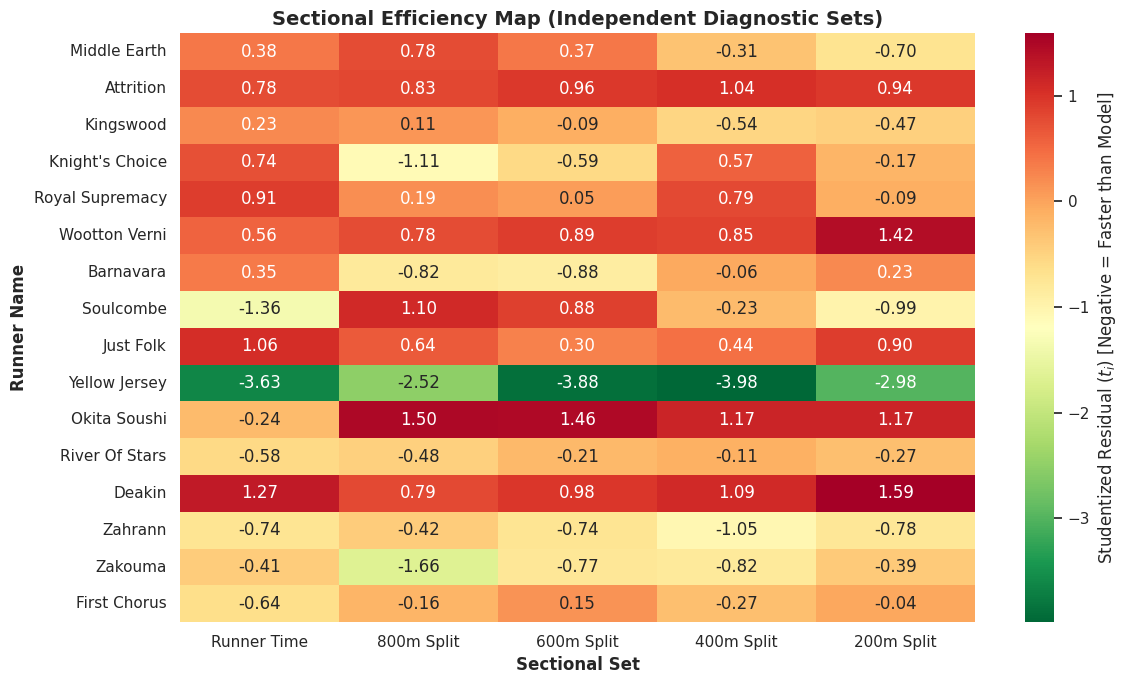

=== TOP 'GOOD OUTLIERS' (FASTER THAN PREDICTED BY EARLY PACE) ===
• Runner Time  -> Yellow Jersey (t_i = -3.63)
• 800m Split   -> Yellow Jersey (t_i = -2.52)
• 600m Split   -> Yellow Jersey (t_i = -3.88)
• 400m Split   -> Yellow Jersey (t_i = -3.98)
• 200m Split   -> Yellow Jersey (t_i = -2.98)


In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# ------------------------------------------------------------------------------
# 1. PARSE & CLEAN DATA
# ------------------------------------------------------------------------------
data = """
tab_num	runner_name	runner_time	early_pace	split_800m	split_600m	split_400m	split_200m
1	Middle Earth	-5.39L	42	-2.05L	-1.84L	-1.36L	-0.58L
2	Attrition	-3.89L	41	-2.01L	-1.47L	-0.78L	-0.20L
3	Kingswood	-11.37L	58	-2.62L	-2.08L	-1.38L	-0.46L
4	Knight's Choice	-2.99L	38	-3.43L	-2.50L	-0.99L	-0.47L
5	Royal Supremacy	-10.05L	60	-2.57L	-1.98L	-0.78L	-0.36L
6	Wootton Verni	-12.80L	65	-2.15L	-1.40L	-0.73L	+0.00L
7	Barnavara	-17.26L	76	-3.38L	-2.50L	-1.07L	-0.22L
8	Soulcombe	-26.18L	89	-2.13L	-1.37L	-1.07L	-0.42L
9	Just Folk	-10.34L	62	-2.24L	-1.80L	-0.92L	-0.12L
10	Yellow Jersey	-19.61L	57	-4.32L	-3.84L	-2.36L	-0.91L
11	Okita Soushi	-6.24L	39	-1.56L	-1.19L	-0.74L	-0.16L
12	River Of Stars	-12.45L	54	-3.06L	-2.18L	-1.21L	-0.43L
13	Deakin	-8.73L	59	-2.11L	-1.37L	-0.66L	+0.01L
14	Zahrann	+3.05L	9	-2.75L	-2.64L	-1.76L	-0.70L
15	Zakouma	-17.45L	70	-3.91L	-2.47L	-1.43L	-0.39L
16	First Chorus	-3.55L	28	-2.69L	-2.06L	-1.41L	-0.48L

"""

df = pd.read_csv(StringIO(data.strip()), sep='\t')
cols_to_clean = ['runner_time', 'split_800m', 'split_600m', 'split_400m', 'split_200m']
for col in cols_to_clean:
    df[col] = df[col].astype(str).str.replace('L', '').str.replace('+', '').astype(float)

# Filter out extreme non-contender (Buckaroo) to keep baseline clean
df_clean = df[df['runner_name'] != 'Buckaroo'].copy().reset_index(drop=True)

# ------------------------------------------------------------------------------
# 2. RUN DIAGNOSTIC REGRESSIONS FOR EACH TARGET METRIC SET
# ------------------------------------------------------------------------------
target_sets = {
    'Runner Time': 'runner_time',
    '800m Split': 'split_800m',
    '600m Split': 'split_600m',
    '400m Split': 'split_400m',
    '200m Split': 'split_200m'
}

residual_summary = pd.DataFrame({'tab_num': df_clean['tab_num'], 'runner_name': df_clean['runner_name']})
leverage_summary = pd.DataFrame({'tab_num': df_clean['tab_num'], 'runner_name': df_clean['runner_name']})

for set_name, col in target_sets.items():
    X = sm.add_constant(df_clean['early_pace'])
    y = df_clean[col]

    model = sm.OLS(y, X).fit()
    influence = model.get_influence()

    # Store Studentized Residuals (t_i) and Leverage (h_ii)
    residual_summary[set_name] = influence.resid_studentized_external
    leverage_summary[set_name] = influence.hat_matrix_diag

# ------------------------------------------------------------------------------
# 3. HEATMAP VISUALIZATION OF SECTIONAL EFFICIENCY (t_i)
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")

# Set up plot data indexed by runner name
heatmap_data = residual_summary.set_index('runner_name').drop(columns=['tab_num'])

# Plot Heatmap
# Green = Faster than predicted (Good Outlier)
# Red = Slower than predicted (Bad Outlier)
ax = sns.heatmap(
    heatmap_data,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".2f",
    cbar_kws={'label': r'Studentized Residual ($t_i$) [Negative = Faster than Model]'}
)
plt.title("Sectional Efficiency Map (Independent Diagnostic Sets)", fontsize=14, fontweight='bold')
plt.ylabel("Runner Name", fontweight='bold')
plt.xlabel("Sectional Set", fontweight='bold')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4. PRINT "GOOD OUTLIERS" PER SET
# ------------------------------------------------------------------------------
print("=== TOP 'GOOD OUTLIERS' (FASTER THAN PREDICTED BY EARLY PACE) ===")
for set_name in target_sets.keys():
    best_runner = residual_summary.sort_values(by=set_name).iloc[0]
    print(f"• {set_name:12s} -> {best_runner['runner_name']} (t_i = {best_runner[set_name]:.2f})")